In [1]:
import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv('punchingstats.csv')

# Preview data
df.head()

,Unnamed: 0.1,Unnamed: 0,name,wins,losses,draws,average_weight,sex,division,Jab accuracy,...,Total punch accuracy,Avg Jabs landed,Avg Power punches landed,Avg Total punches landed,% of Power punches landed against,% of Jabs landed against,% of Total punches landed against,Avg Jabs landed against,Avg Power punches landed against,Avg Total punches landed against
0,0,0,Nikita Ababiy,7.0,0.0,0.0,160.75,male,middle,14.29,...,34.48,1.0,9.0,10.0,10.34,12.50,10.81,1.0,3.0,4.0
1,1,1,Joey Abell,35.0,10.0,0.0,244.69,male,heavy,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0
2,2,2,Berlin Abreu,14.0,3.0,0.0,NaN,male,welter,9.72,...,18.26,24.0,81.0,105.0,25.74,12.81,17.88,47.0,61.0,108.0
3,3,3,Herbert Acevedo,16.0,2.0,1.0,138.97,male,super light,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0
4,4,4,Richard Acevedo,5.0,0.0,1.0,152.79,male,super welter,8.62,...,32.51,2.5,37.0,39.5,26.73,16.67,23.78,7.0,27.0,34.0


In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.fillna('')

In [6]:
df.columns = df.columns.str.strip().str.lower()

In [7]:
print(df.columns)

Index(['unnamed: 0.1', 'unnamed: 0', 'name', 'wins', 'losses', 'draws',
       'average_weight', 'sex', 'division', 'jab accuracy',
       'power punch accuracy', 'total punch accuracy', 'avg jabs landed',
       'avg power punches landed', 'avg total punches landed',
       '% of power punches landed against', '% of jabs landed against',
       '% of total punches landed against', 'avg jabs landed against',
       'avg power punches landed against', 'avg total punches landed against'],
      dtype='str')


In [10]:
print(df.columns)
print(df.head())

Index(['unnamed: 0.1', 'unnamed: 0', 'name', 'wins', 'losses', 'draws',
       'average_weight', 'sex', 'division', 'jab accuracy',
       'power punch accuracy', 'total punch accuracy', 'avg jabs landed',
       'avg power punches landed', 'avg total punches landed',
       '% of power punches landed against', '% of jabs landed against',
       '% of total punches landed against', 'avg jabs landed against',
       'avg power punches landed against', 'avg total punches landed against'],
      dtype='str')
   unnamed: 0.1  unnamed: 0             name  wins  losses  draws  \
0             0           0    Nikita Ababiy   7.0     0.0    0.0   
1             1           1       Joey Abell  35.0    10.0    0.0   
2             2           2     Berlin Abreu  14.0     3.0    0.0   
3             3           3  Herbert Acevedo  16.0     2.0    1.0   
4             4           4  Richard Acevedo   5.0     0.0    1.0   

  average_weight   sex      division jab accuracy  ... total punch accurac

In [13]:
# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Select text columns
text_df = df.select_dtypes(include=['object', 'string'])

# Now check shapes
print(numeric_df.shape)
print(text_df.shape)

(540, 8)
(540, 13)


In [16]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Example dataframe
final_df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6]
})

scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_df)

print(scaled_data)

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


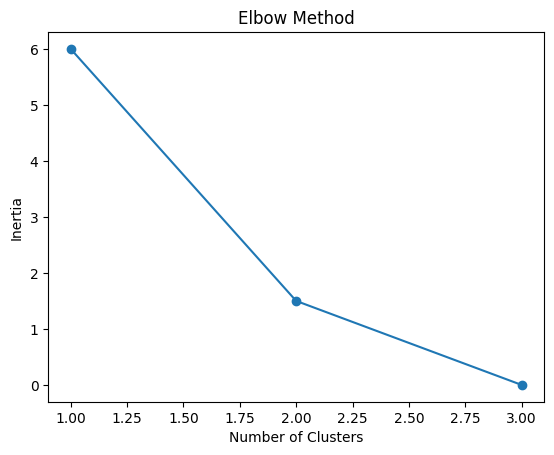

In [18]:
n_samples = scaled_data.shape[0]

inertia = []

for k in range(1, min(11, n_samples + 1)):  # ensures k <= n_samples
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, len(inertia) + 1), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [20]:
print(df.shape)
print(scaled_data.shape)

(540, 21)
(3, 2)


In [22]:
if 'cluster' in df.columns:
    print(df['cluster'].value_counts())
else:
    print("No 'cluster' column found")

No 'cluster' column found


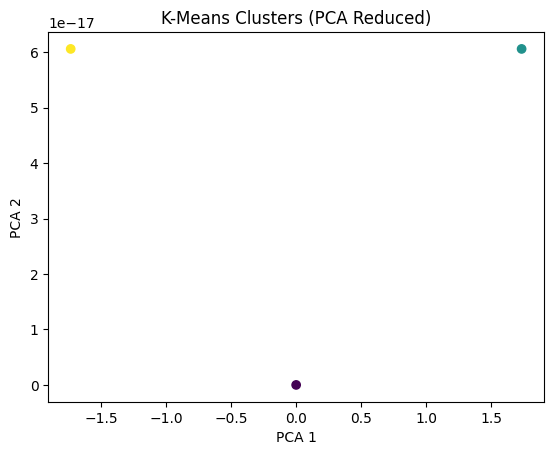

In [25]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(scaled_data)

# PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

# Plot
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis')
plt.title('K-Means Clusters (PCA Reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()